# Dataset Overview
PPG+Dalia dataset is benchmark dataset for photoplethysmography (ppg) signal analysis and heart rate estimation 

15 subjects performing various activities
Wrist-worn PPG sensors and chest ECG reference
Field study with real-world conditions
Multiple activities: sitting, walking, working, etc.
Ground truth heart rate from ECG

# Cellule 1: Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import glob
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, find_peaks
import warnings
warnings.filterwarnings('ignore')

# Set up beautiful plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print("🎨 PPG+Dalia Dataset Visualization Tool")
print("=" * 60)

🎨 PPG+Dalia Dataset Visualization Tool


# Cellule 2: Classe PPGDaliaDataExplorer

In [2]:
class PPGDaliaDataExplorer:
    def __init__(self):
        self.subjects_data = {}
        self.dataset_stats = {}
        
    def find_dataset_automatically(self):
        """Automatically find PPG+Dalia dataset"""
        path = r"C:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S"
        
        if os.path.exists(path):
            pickle_files = glob.glob(os.path.join(path, "*.pkl"))
            if pickle_files:
                print(f"✅ Found dataset at: {path}")
                print(f"📁 Found {len(pickle_files)} subject files")
                return path
        
        print("❌ Dataset not found automatically!")
        print("📋 Please ensure your dataset is in this location:")
        print(f"   - {path}")
        return None

    def load_single_subject(self, file_path):
        """Load a single subject's data with multiple encoding attempts"""
        try:
            data = None
            loading_methods = [
                lambda f: pickle.load(f, encoding='latin-1'),
                lambda f: pickle.load(f, encoding='bytes'),
                lambda f: pickle.load(f)
            ]
            
            for method in loading_methods:
                try:
                    with open(file_path, 'rb') as f:
                        data = method(f)
                    break
                except:
                    continue
            
            if data is None:
                return None
            
            # Process byte keys to strings
            if isinstance(data, dict):
                processed_data = {}
                for key, value in data.items():
                    if isinstance(key, bytes):
                        try:
                            key = key.decode('utf-8', errors='ignore')
                        except:
                            key = str(key)
                    processed_data[key] = value
                data = processed_data
            
            return data
            
        except Exception as e:
            print(f"⚠️  Could not load {os.path.basename(file_path)}: {e}")
            return None

    def extract_signals_from_subject(self, subject_data):
        """Extract PPG and HR signals from subject data"""
        signals = {}
        
        # Extract PPG signal
        ppg_signal = None
        if 'signal' in subject_data and isinstance(subject_data['signal'], dict):
            signal_dict = subject_data['signal']
            
            # Look for wrist PPG (BVP = Blood Volume Pulse)
            if 'wrist' in signal_dict and isinstance(signal_dict['wrist'], dict):
                wrist_data = signal_dict['wrist']
                if 'BVP' in wrist_data:
                    ppg_signal = np.array(wrist_data['BVP'])
                
                # Also extract other wrist signals if available
                if 'EDA' in wrist_data:
                    signals['eda'] = np.array(wrist_data['EDA'])
                if 'TEMP' in wrist_data:
                    signals['temperature'] = np.array(wrist_data['TEMP'])
            
            # Look for chest ECG as reference
            if 'chest' in signal_dict and isinstance(signal_dict['chest'], dict):
                chest_data = signal_dict['chest']
                if 'ECG' in chest_data:
                    signals['ecg'] = np.array(chest_data['ECG'])
        
        # Extract HR labels (ground truth)
        hr_labels = None
        if 'label' in subject_data:
            hr_labels = np.array(subject_data['label'])
        
        if ppg_signal is not None:
            signals['ppg'] = ppg_signal
        if hr_labels is not None:
            signals['hr_labels'] = hr_labels
            
        return signals

    def load_all_subjects(self, data_path):
        """Load all subjects from the dataset"""
        if not os.path.exists(data_path):
            print(f"❌ Path not found: {data_path}")
            return False
        
        pickle_files = glob.glob(os.path.join(data_path, "*.pkl"))
        if not pickle_files:
            print(f"❌ No .pkl files found in {data_path}")
            return False
        
        print(f"📊 Loading {len(pickle_files)} subjects...")
        loaded_count = 0
        
        for file_path in pickle_files:
            subject_id = os.path.basename(file_path).replace('.pkl', '')
            subject_data = self.load_single_subject(file_path)
            
            if subject_data:
                signals = self.extract_signals_from_subject(subject_data)
                
                if 'ppg' in signals and 'hr_labels' in signals:
                    self.subjects_data[subject_id] = signals
                    loaded_count += 1
                    print(f"   ✅ {subject_id}: PPG({len(signals['ppg'])}) HR({len(signals['hr_labels'])})")
                else:
                    print(f"   ⚠️  {subject_id}: Missing PPG or HR data")
            else:
                print(f"   ❌ {subject_id}: Could not load")
        
        print(f"\n🎉 Successfully loaded {loaded_count} subjects with complete data!")
        return loaded_count > 0

    def analyze_dataset_structure(self):
        """Analyze and print dataset structure"""
        if not self.subjects_data:
            print("❌ No data loaded!")
            return
        
        print(f"\n📋 DATASET STRUCTURE ANALYSIS")
        print("=" * 60)
        
        total_subjects = len(self.subjects_data)
        total_duration = 0
        all_hr_values = []
        signal_types = set()
        
        # Collect statistics
        for subject_id, signals in self.subjects_data.items():
            duration_min = len(signals['ppg']) / 64 / 60  # 64 Hz sampling rate
            total_duration += duration_min
            
            # Sample HR values (every 64th sample = 1 Hz)
            hr_sampled = signals['hr_labels'][::64]
            all_hr_values.extend(hr_sampled)
            
            # Collect signal types
            signal_types.update(signals.keys())
        
        # Print summary
        print(f"📊 Total Subjects: {total_subjects}")
        print(f"⏱️  Total Duration: {total_duration:.1f} minutes ({total_duration/60:.1f} hours)")
        print(f"📈 Signal Types: {', '.join(signal_types)}")
        print(f"❤️  HR Range: {np.min(all_hr_values):.1f} - {np.max(all_hr_values):.1f} BPM")
        print(f"📊 Mean HR: {np.mean(all_hr_values):.1f} ± {np.std(all_hr_values):.1f} BPM")
        print(f"🔢 Total HR Samples: {len(all_hr_values):,}")
        
        # Store stats for later use
        self.dataset_stats = {
            'total_subjects': total_subjects,
            'total_duration': total_duration,
            'all_hr_values': all_hr_values,
            'signal_types': list(signal_types)
        }

# Cellule 3: Dashboard de visualisation

In [3]:
def create_dataset_overview_dashboard(self):
    """Create comprehensive dataset overview"""
    if not self.subjects_data or not self.dataset_stats:
        print("❌ No data available for visualization")
        return
    
    print("\n🎨 Creating Dataset Overview Dashboard...")
    
    # Prepare data
    subject_stats = []
    for subject_id, signals in self.subjects_data.items():
        ppg = signals['ppg']
        hr = signals['hr_labels']
        
        stats = {
            'subject_id': subject_id,
            'duration_min': len(ppg) / 64 / 60,
            'ppg_samples': len(ppg),
            'hr_samples': len(hr),
            'hr_mean': np.mean(hr),
            'hr_std': np.std(hr),
            'hr_min': np.min(hr),
            'hr_max': np.max(hr),
            'hr_range': np.max(hr) - np.min(hr)
        }
        subject_stats.append(stats)
    
    stats_df = pd.DataFrame(subject_stats)
    all_hr = self.dataset_stats['all_hr_values']
    
    # Create dashboard
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Overall HR Distribution
    axes[0, 0].hist(all_hr, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(np.mean(all_hr), color='red', linestyle='--', linewidth=2,
                        label=f'Mean: {np.mean(all_hr):.1f} BPM')
    axes[0, 0].set_title('❤️ Heart Rate Distribution (All Subjects)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Heart Rate (BPM)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Subject-wise HR Statistics
    x_pos = range(len(stats_df))
    bars = axes[0, 1].bar(x_pos, stats_df['hr_mean'], yerr=stats_df['hr_std'],
                            capsize=5, alpha=0.7, color='lightcoral')
    axes[0, 1].set_title('📊 Mean HR by Subject (±1 STD)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Subject')
    axes[0, 1].set_ylabel('Heart Rate (BPM)')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(stats_df['subject_id'], rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Recording Duration
    colors = plt.cm.Set3(np.linspace(0, 1, len(stats_df)))
    bars = axes[0, 2].bar(x_pos, stats_df['duration_min'], color=colors, alpha=0.7)
    axes[0, 2].set_title('⏱️ Recording Duration by Subject', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Subject')
    axes[0, 2].set_ylabel('Duration (minutes)')
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels(stats_df['subject_id'], rotation=45)
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. HR Range by Subject
    axes[1, 0].bar(x_pos, stats_df['hr_range'], color='lightgreen', alpha=0.7)
    axes[1, 0].set_title('📈 HR Range (Max - Min) by Subject', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Subject')
    axes[1, 0].set_ylabel('HR Range (BPM)')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(stats_df['subject_id'], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. HR Categories Distribution
    hr_categories = []
    for hr in all_hr:
        if hr < 70:
            hr_categories.append('Low (< 70)')
        elif hr < 100:
            hr_categories.append('Normal (70-100)')
        else:
            hr_categories.append('High (≥ 100)')
    
    category_counts = pd.Series(hr_categories).value_counts()
    colors_cat = ['lightcoral', 'lightgreen', 'orange']
    axes[1, 1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
                    colors=colors_cat, startangle=90)
    axes[1, 1].set_title('📊 HR Categories Distribution', fontsize=14, fontweight='bold')
    
    # 6. Box plot of HR by subject (first 8 subjects for clarity)
    hr_by_subject = []
    subject_names = []
    for _, row in stats_df.head(8).iterrows():
        subject_id = row['subject_id']
        hr_data = self.subjects_data[subject_id]['hr_labels'][::320]  # Sample every 5 seconds
        hr_by_subject.append(hr_data)
        subject_names.append(subject_id)
    
    axes[1, 2].boxplot(hr_by_subject, labels=subject_names)
    axes[1, 2].set_title('📦 HR Distribution by Subject (Box Plot)', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Subject')
    axes[1, 2].set_ylabel('Heart Rate (BPM)')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle('📊 PPG+Dalia Dataset Overview Dashboard', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📋 DASHBOARD SUMMARY:")
    print(f"   📊 Subjects visualized: {len(stats_df)}")
    print(f"   ⏱️  Total time: {self.dataset_stats['total_duration']:.1f} minutes")
    print(f"   ❤️  HR categories: {dict(category_counts)}")
    print(f"   📈 Average recording: {stats_df['duration_min'].mean():.1f} ± {stats_df['duration_min'].std():.1f} min")

# Add method to class
PPGDaliaDataExplorer.create_dataset_overview_dashboard = create_dataset_overview_dashboard

# Cellule 4: Exploration détaillée d'un sujet

In [4]:
def explore_single_subject(self, subject_id=None, time_window=300):
        """Detailed exploration of a single subject"""
        if not self.subjects_data:
            print("❌ No data loaded!")
            return
        
        # Use first subject if none specified
        if subject_id is None:
            subject_id = list(self.subjects_data.keys())[0]
        
        if subject_id not in self.subjects_data:
            print(f"❌ Subject {subject_id} not found")
            print(f"Available subjects: {list(self.subjects_data.keys())}")
            return
        
        signals = self.subjects_data[subject_id]
        ppg = signals['ppg']
        hr = signals['hr_labels']
        
        print(f"\n🔬 EXPLORING SUBJECT: {subject_id}")
        print("=" * 50)
        print(f"   📊 PPG samples: {len(ppg):,}")
        print(f"   ❤️  HR samples: {len(hr):,}")
        print(f"   ⏱️  Duration: {len(ppg)/64/60:.1f} minutes")
        print(f"   📈 HR range: {np.min(hr):.1f} - {np.max(hr):.1f} BPM")
        
        # Select time window for visualization
        fs = 64  # Sampling frequency
        start_time = min(60, len(ppg)//fs - time_window)  # Start at 1 minute or adjust if signal is short
        start_idx = max(0, start_time * fs)
        end_idx = min(start_idx + time_window * fs, len(ppg))
        
        # Ensure we have enough data
        if end_idx - start_idx < 100:  # At least 100 samples
            print(f"⚠️  Signal too short, using all available data")
            start_idx = 0
            end_idx = len(ppg)
        
        ppg_window = ppg[start_idx:end_idx]
        hr_window = hr[start_idx:min(end_idx, len(hr))]
        
        # Time vectors
        t_ppg = np.arange(len(ppg_window)) / fs
        t_hr = np.arange(len(hr_window)) / fs
        
        actual_window = len(ppg_window) / fs
        print(f"   🖼️  Showing {actual_window:.1f} seconds (from {start_time}s)")
        
        # Create detailed visualization
        fig, axes = plt.subplots(3, 2, figsize=(20, 15))
        
        # 1. Raw PPG Signal
        axes[0, 0].plot(t_ppg, ppg_window, 'b-', linewidth=1, alpha=0.8)
        axes[0, 0].set_title(f'📊 Raw PPG Signal - {subject_id}', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Amplitude')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_xlim(0, max(t_ppg) if len(t_ppg) > 0 else 1)
        
        # 2. Filtered PPG Signal (FIXED)
        filtered_ppg = ppg_window.copy()  # Default to original signal
        
        # Only apply filter if we have enough data points
        min_length_required = 64  # Minimum samples needed for filtering
        
        if len(ppg_window) > min_length_required:
            try:
                nyquist = fs / 2
                low = 0.5 / nyquist
                high = min(4.0 / nyquist, 0.95)  # Ensure high freq is below Nyquist
                
                # Create filter
                b, a = butter(2, [low, high], btype='band')  # Reduced order to 2
                
                # Apply filter with proper padding
                filtered_ppg = filtfilt(b, a, ppg_window)
                filter_label = '🔧 Filtered PPG (0.5-4 Hz)'
                
            except Exception as e:
                print(f"   ⚠️  Filter failed, using raw signal: {e}")
                filtered_ppg = ppg_window
                filter_label = '🔧 PPG (Filter Failed - Raw Signal)'
        else:
            filter_label = f'🔧 PPG (Too short for filtering - {len(ppg_window)} samples)'
        
        axes[0, 1].plot(t_ppg, filtered_ppg, 'g-', linewidth=1.5)
        axes[0, 1].set_title(filter_label, fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('Amplitude')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].set_xlim(0, max(t_ppg) if len(t_ppg) > 0 else 1)
        
        # 3. Heart Rate Signal
        axes[1, 0].plot(t_hr, hr_window, 'r-', linewidth=2)
        axes[1, 0].set_title('❤️ Ground Truth Heart Rate', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('HR (BPM)')
        axes[1, 0].set_xlabel('Time (seconds)')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_xlim(0, max(t_hr) if len(t_hr) > 0 else 1)
        
        # Add HR statistics
        if len(hr_window) > 0:
            hr_mean = np.mean(hr_window)
            hr_std = np.std(hr_window)
            axes[1, 0].axhline(hr_mean, color='orange', linestyle='--', alpha=0.7,
                              label=f'Mean: {hr_mean:.1f} ± {hr_std:.1f} BPM')
            axes[1, 0].legend()
        
        # 4. Frequency Analysis (IMPROVED)
        if len(filtered_ppg) > 256:  # Need enough samples for meaningful FFT
            try:
                # Use a reasonable window for better frequency resolution
                fft_window_size = min(len(filtered_ppg), 64 * 30)  # Max 30 seconds
                fft_window = filtered_ppg[:fft_window_size]
                
                # Apply window function to reduce spectral leakage
                windowed_signal = fft_window * np.hanning(len(fft_window))
                
                fft_ppg = fft(windowed_signal)
                freqs = fftfreq(len(windowed_signal), 1/fs)
                hr_freqs = freqs * 60  # Convert to BPM
                
                # Keep positive frequencies in HR range
                hr_mask = (hr_freqs >= 40) & (hr_freqs <= 180)
                hr_freqs_filtered = hr_freqs[hr_mask]
                fft_magnitude = np.abs(fft_ppg[hr_mask])
                
                if len(hr_freqs_filtered) > 0 and len(fft_magnitude) > 0:
                    axes[1, 1].plot(hr_freqs_filtered, fft_magnitude, 'purple', linewidth=2)
                    axes[1, 1].set_title('🌊 Frequency Spectrum', fontsize=14, fontweight='bold')
                    axes[1, 1].set_xlabel('Heart Rate (BPM)')
                    axes[1, 1].set_ylabel('Magnitude')
                    axes[1, 1].grid(True, alpha=0.3)
                    
                    # Find and mark dominant frequency
                    if len(fft_magnitude) > 0 and np.max(fft_magnitude) > 0:
                        dominant_idx = np.argmax(fft_magnitude)
                        dominant_hr = hr_freqs_filtered[dominant_idx]
                        axes[1, 1].axvline(dominant_hr, color='red', linestyle='--',
                                          label=f'Dominant: {dominant_hr:.1f} BPM')
                        axes[1, 1].legend()
                        
                        print(f"   🌊 Dominant frequency: {dominant_hr:.1f} BPM")
                        if len(hr_window) > 0:
                            print(f"   🎯 Frequency vs actual: {abs(hr_mean - dominant_hr):.1f} BPM difference")
                else:
                    axes[1, 1].text(0.5, 0.5, 'Insufficient data\nfor frequency analysis', 
                                   ha='center', va='center', transform=axes[1, 1].transAxes)
                    axes[1, 1].set_title('🌊 Frequency Analysis (Insufficient Data)', fontsize=14, fontweight='bold')
                    
            except Exception as e:
                print(f"   ⚠️  FFT analysis failed: {e}")
                axes[1, 1].text(0.5, 0.5, f'FFT analysis failed:\n{str(e)[:50]}...', 
                               ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('🌊 Frequency Analysis (Failed)', fontsize=14, fontweight='bold')
        else:
            axes[1, 1].text(0.5, 0.5, f'Signal too short for FFT\n({len(filtered_ppg)} samples)', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('🌊 Frequency Analysis (Too Short)', fontsize=14, fontweight='bold')
        
        # 5. PPG Signal Quality Assessment
        if len(ppg_window) > 0:
            signal_std = np.std(ppg_window)
            signal_mean = np.mean(np.abs(ppg_window))
            quality_ratio = signal_std / (signal_mean + 1e-8)
            
            # PPG characteristics
            ppg_stats = {
                'Mean': np.mean(ppg_window),
                'Std': signal_std,
                'Min': np.min(ppg_window),
                'Max': np.max(ppg_window),
                'Range': np.max(ppg_window) - np.min(ppg_window),
                'Quality': quality_ratio
            }
            
            stats_names = list(ppg_stats.keys())
            stats_values = list(ppg_stats.values())
            
            bars = axes[2, 0].bar(range(len(stats_names)), stats_values, alpha=0.7, color='lightblue')
            axes[2, 0].set_title('📈 PPG Signal Characteristics', fontsize=14, fontweight='bold')
            axes[2, 0].set_xlabel('Metric')
            axes[2, 0].set_ylabel('Value')
            axes[2, 0].set_xticks(range(len(stats_names)))
            axes[2, 0].set_xticklabels(stats_names, rotation=45)
            axes[2, 0].grid(True, alpha=0.3)
            
            # Add value labels on bars
            for bar, value in zip(bars, stats_values):
                height = bar.get_height()
                axes[2, 0].text(bar.get_x() + bar.get_width()/2., height + abs(height)*0.01,
                               f'{value:.2f}', ha='center', va='bottom', fontsize=10)
        
        # 6. HR Categories Analysis
        if len(hr_window) > 1:
            sample_step = max(1, len(hr_window) // 100)  # Sample at most 100 points
            hr_categories = []
            for hr_val in hr_window[::sample_step]:
                if hr_val < 70:
                    hr_categories.append('Low')
                elif hr_val < 100:
                    hr_categories.append('Normal') 
                else:
                    hr_categories.append('High')
            
            if hr_categories:
                category_counts = pd.Series(hr_categories).value_counts()
                
                if len(category_counts) > 0:
                    axes[2, 1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
                                  colors=['lightcoral', 'lightgreen', 'orange'], startangle=90)
                    axes[2, 1].set_title(f'📊 HR Categories - {subject_id}', fontsize=14, fontweight='bold')
                else:
                    axes[2, 1].text(0.5, 0.5, 'No HR categories\nto display', 
                                   ha='center', va='center', transform=axes[2, 1].transAxes)
            else:
                axes[2, 1].text(0.5, 0.5, 'Insufficient HR data\nfor categorization', 
                               ha='center', va='center', transform=axes[2, 1].transAxes)
        else:
            axes[2, 1].text(0.5, 0.5, 'No HR data available', 
                           ha='center', va='center', transform=axes[2, 1].transAxes)
        
        plt.suptitle(f'🔬 Detailed Analysis: Subject {subject_id}', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Additional analysis with other signals if available
        if 'eda' in signals or 'temperature' in signals or 'ecg' in signals:
            self.show_additional_signals(subject_id, signals, start_idx, end_idx)

# Add method to class
PPGDaliaDataExplorer.explore_single_subject = explore_single_subject

# Cellule 5: Méthodes complémentaires

In [5]:
def show_additional_signals(self, subject_id, signals, start_idx, end_idx):
    """Show additional signals if available"""
    available_signals = [k for k in ['eda', 'temperature', 'ecg'] if k in signals]
    
    if not available_signals:
        return
    
    print(f"\n📊 Additional signals available for {subject_id}: {available_signals}")
    
    fig, axes = plt.subplots(len(available_signals), 1, figsize=(15, 4*len(available_signals)))
    if len(available_signals) == 1:
        axes = [axes]
    
    fs_dict = {'eda': 4, 'temperature': 4, 'ecg': 700}  # Typical sampling rates
    
    for i, signal_name in enumerate(available_signals):
        signal_data = signals[signal_name]
        fs = fs_dict.get(signal_name, 64)
        
        # Adjust indices for different sampling rates
        start_signal = int(start_idx * fs / 64)
        end_signal = int(end_idx * fs / 64)
        start_signal = min(start_signal, len(signal_data) - 1)
        end_signal = min(end_signal, len(signal_data))
        
        if start_signal < end_signal:
            signal_window = signal_data[start_signal:end_signal]
            t_signal = np.arange(len(signal_window)) / fs
            
            if signal_name == 'ecg':
                # Downsample ECG for visualization (700 Hz is too dense)
                step = max(1, len(signal_window) // 5000)  # Max 5000 points
                signal_window = signal_window[::step]
                t_signal = t_signal[::step]
            
            axes[i].plot(t_signal, signal_window, linewidth=1.5)
            axes[i].set_title(f'📊 {signal_name.upper()} Signal - {subject_id}', 
                                fontsize=14, fontweight='bold')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True, alpha=0.3)
            
            if i == len(available_signals) - 1:
                axes[i].set_xlabel('Time (seconds)')
    
    plt.suptitle(f'📈 Additional Physiological Signals - {subject_id}', 
                    fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def compare_multiple_subjects(self, subject_list=None, comparison_window=120):
    """Compare multiple subjects side by side"""
    if not self.subjects_data:
        print("❌ No data loaded!")
        return
    
    # Use first 4 subjects if none specified
    if subject_list is None:
        subject_list = list(self.subjects_data.keys())[:4]
    
    # Filter to available subjects
    available_subjects = [s for s in subject_list if s in self.subjects_data]
    
    if not available_subjects:
        print("❌ No valid subjects found for comparison")
        return
    
    print(f"\n🔍 COMPARING SUBJECTS: {available_subjects}")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
    
    for i, subject_id in enumerate(available_subjects[:4]):
        signals = self.subjects_data[subject_id]
        ppg = signals['ppg']
        hr = signals['hr_labels']
        
        # Select window with safety checks
        fs = 64
        max_start = max(0, len(ppg)//fs - comparison_window - 60)  # Leave room for window
        start_idx = min(60 * fs, max_start * fs)  # Start at 1 minute or earlier if needed
        end_idx = min(start_idx + comparison_window * fs, len(ppg))
        
        # Ensure minimum data
        if end_idx - start_idx < 100:
            start_idx = 0
            end_idx = min(len(ppg), comparison_window * fs)
        
        ppg_window = ppg[start_idx:end_idx] if start_idx < len(ppg) else ppg[-100:]
        hr_window = hr[start_idx:min(end_idx, len(hr))] if start_idx < len(hr) else hr[-100:]
        
        t_ppg = np.arange(len(ppg_window)) / fs
        t_hr = np.arange(len(hr_window)) / fs
        
        # Plot PPG
        if i < 2:
            axes[i].plot(t_ppg, ppg_window, color=colors[i], linewidth=1, alpha=0.8)
            axes[i].set_title(f'📊 PPG - {subject_id}', fontsize=14, fontweight='bold')
            axes[i].set_ylabel('PPG Amplitude')
            axes[i].grid(True, alpha=0.3)
        
        # Plot HR
        if i >= 2:
            axes[i].plot(t_hr, hr_window, color=colors[i], linewidth=2)
            axes[i].set_title(f'❤️ HR - {available_subjects[i-2]}', fontsize=14, fontweight='bold')
            axes[i].set_ylabel('Heart Rate (BPM)')
            axes[i].set_xlabel('Time (seconds)')
            axes[i].grid(True, alpha=0.3)
            
            # Add mean line
            if len(hr_window) > 0:
                hr_mean = np.mean(hr_window)
                axes[i].axhline(hr_mean, color=colors[i], linestyle='--', alpha=0.7,
                                label=f'Mean: {hr_mean:.1f} BPM')
                axes[i].legend()
    
    plt.suptitle(f'🔍 Multi-Subject Comparison ({comparison_window}s windows)', 
                    fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print(f"\n📊 COMPARISON STATISTICS:")
    for subject_id in available_subjects:
        signals = self.subjects_data[subject_id]
        hr = signals['hr_labels']
        print(f"   {subject_id}: HR {np.mean(hr):.1f}±{np.std(hr):.1f} BPM, "
                f"Duration: {len(signals['ppg'])/64/60:.1f} min")

def interactive_subject_explorer(self):
    """Interactive exploration menu"""
    if not self.subjects_data:
        print("❌ No data loaded!")
        return
    
    subjects = list(self.subjects_data.keys())
    
    while True:
        print(f"\n🎮 INTERACTIVE SUBJECT EXPLORER")
        print("=" * 50)
        print(f"Available subjects: {len(subjects)}")
        print("\nOptions:")
        print("1. Explore specific subject")
        print("2. Compare multiple subjects") 
        print("3. Show dataset overview")
        print("4. List all subjects")
        print("5. Exit")
        
        choice = input("\nEnter your choice (1-5): ").strip()
        
        if choice == '1':
            print(f"\nAvailable subjects: {subjects}")
            subject_id = input("Enter subject ID: ").strip()
            if subject_id in subjects:
                self.explore_single_subject(subject_id)
            else:
                print(f"❌ Subject {subject_id} not found!")
        
        elif choice == '2':
            print(f"\nAvailable subjects: {subjects}")
            subject_input = input("Enter subject IDs (comma-separated): ").strip()
            if subject_input:
                subject_list = [s.strip() for s in subject_input.split(',')]
                self.compare_multiple_subjects(subject_list)
            else:
                self.compare_multiple_subjects()
        
        elif choice == '3':
            self.create_dataset_overview_dashboard()
        
        elif choice == '4':
            print(f"\n📋 All subjects ({len(subjects)}):")
            for i, subject_id in enumerate(subjects, 1):
                signals = self.subjects_data[subject_id]
                duration = len(signals['ppg']) / 64 / 60
                hr_mean = np.mean(signals['hr_labels'])
                print(f"   {i:2d}. {subject_id}: {duration:.1f} min, HR {hr_mean:.1f} BPM")
        
        elif choice == '5':
            print("👋 Goodbye!")
            break
        
        else:
            print("❌ Invalid choice! Please enter 1-5.")

def run_complete_exploration(self, data_path=None):
    """Run complete data exploration pipeline"""
    print("🚀 STARTING PPG+DALIA DATA EXPLORATION")
    print("=" * 80)
    
    # 1. Find dataset
    if data_path is None:
        data_path = self.find_dataset_automatically()
    
    if not data_path:
        print("❌ Cannot proceed without dataset!")
        return False
    
    # 2. Load all subjects
    success = self.load_all_subjects(data_path)
    if not success:
        return False
    
    # 3. Analyze structure
    self.analyze_dataset_structure()
    
    # 4. Create overview dashboard
    self.create_dataset_overview_dashboard()
    
    # 5. Explore first subject in detail (with error handling)
    if self.subjects_data:
        try:
            first_subject = list(self.subjects_data.keys())[0]
            self.explore_single_subject(first_subject)
            
            # 6. Compare first few subjects
            self.compare_multiple_subjects()
            
        except Exception as e:
            print(f"⚠️  Error in detailed exploration: {e}")
            print("Continuing with basic analysis...")
    
    print(f"\n🎉 EXPLORATION COMPLETE!")
    print("💡 Use interactive_subject_explorer() for more detailed exploration")
    
    return True

# Add methods to class
PPGDaliaDataExplorer.show_additional_signals = show_additional_signals
PPGDaliaDataExplorer.compare_multiple_subjects = compare_multiple_subjects
PPGDaliaDataExplorer.interactive_subject_explorer = interactive_subject_explorer
PPGDaliaDataExplorer.run_complete_exploration = run_complete_exploration

# Cellule 6: Fonctions principales et exécution

🎨 Welcome to PPG+Dalia Dataset Visualizer!
🚀 STARTING PPG+DALIA DATA EXPLORATION
✅ Found dataset at: C:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S
📁 Found 15 subject files
📊 Loading 15 subjects...
   ✅ S1: PPG(589568) HR(4603)
   ✅ S10: PPG(681472) HR(5321)
   ✅ S11: PPG(579072) HR(4521)
   ✅ S12: PPG(506496) HR(3954)
   ✅ S13: PPG(584704) HR(4565)
   ✅ S14: PPG(573312) HR(4476)
   ✅ S15: PPG(508096) HR(3966)
   ✅ S2: PPG(525120) HR(4099)
   ✅ S3: PPG(559424) HR(4367)
   ✅ S4: PPG(585600) HR(4572)
   ✅ S5: PPG(595520) HR(4649)
   ✅ S6: PPG(336000) HR(2622)
   ✅ S7: PPG(597952) HR(4668)
   ✅ S8: PPG(517120) HR(4037)
   ✅ S9: PPG(547840) HR(4277)

🎉 Successfully loaded 15 subjects with complete data!

📋 DATASET STRUCTURE ANALYSIS
📊 Total Subjects: 15
⏱️  Total Duration: 2158.2 minutes (36.0 hours)
📈 Signal Types: ppg, temperature, ecg, eda, hr_labels
❤️  HR Range: 41.9 - 180.2 BPM
📊 Mean HR: 89.2 ± 22.8 BPM
🔢 Total HR Samples: 1,017

🎨 Creating Dataset Overview Dashboard...


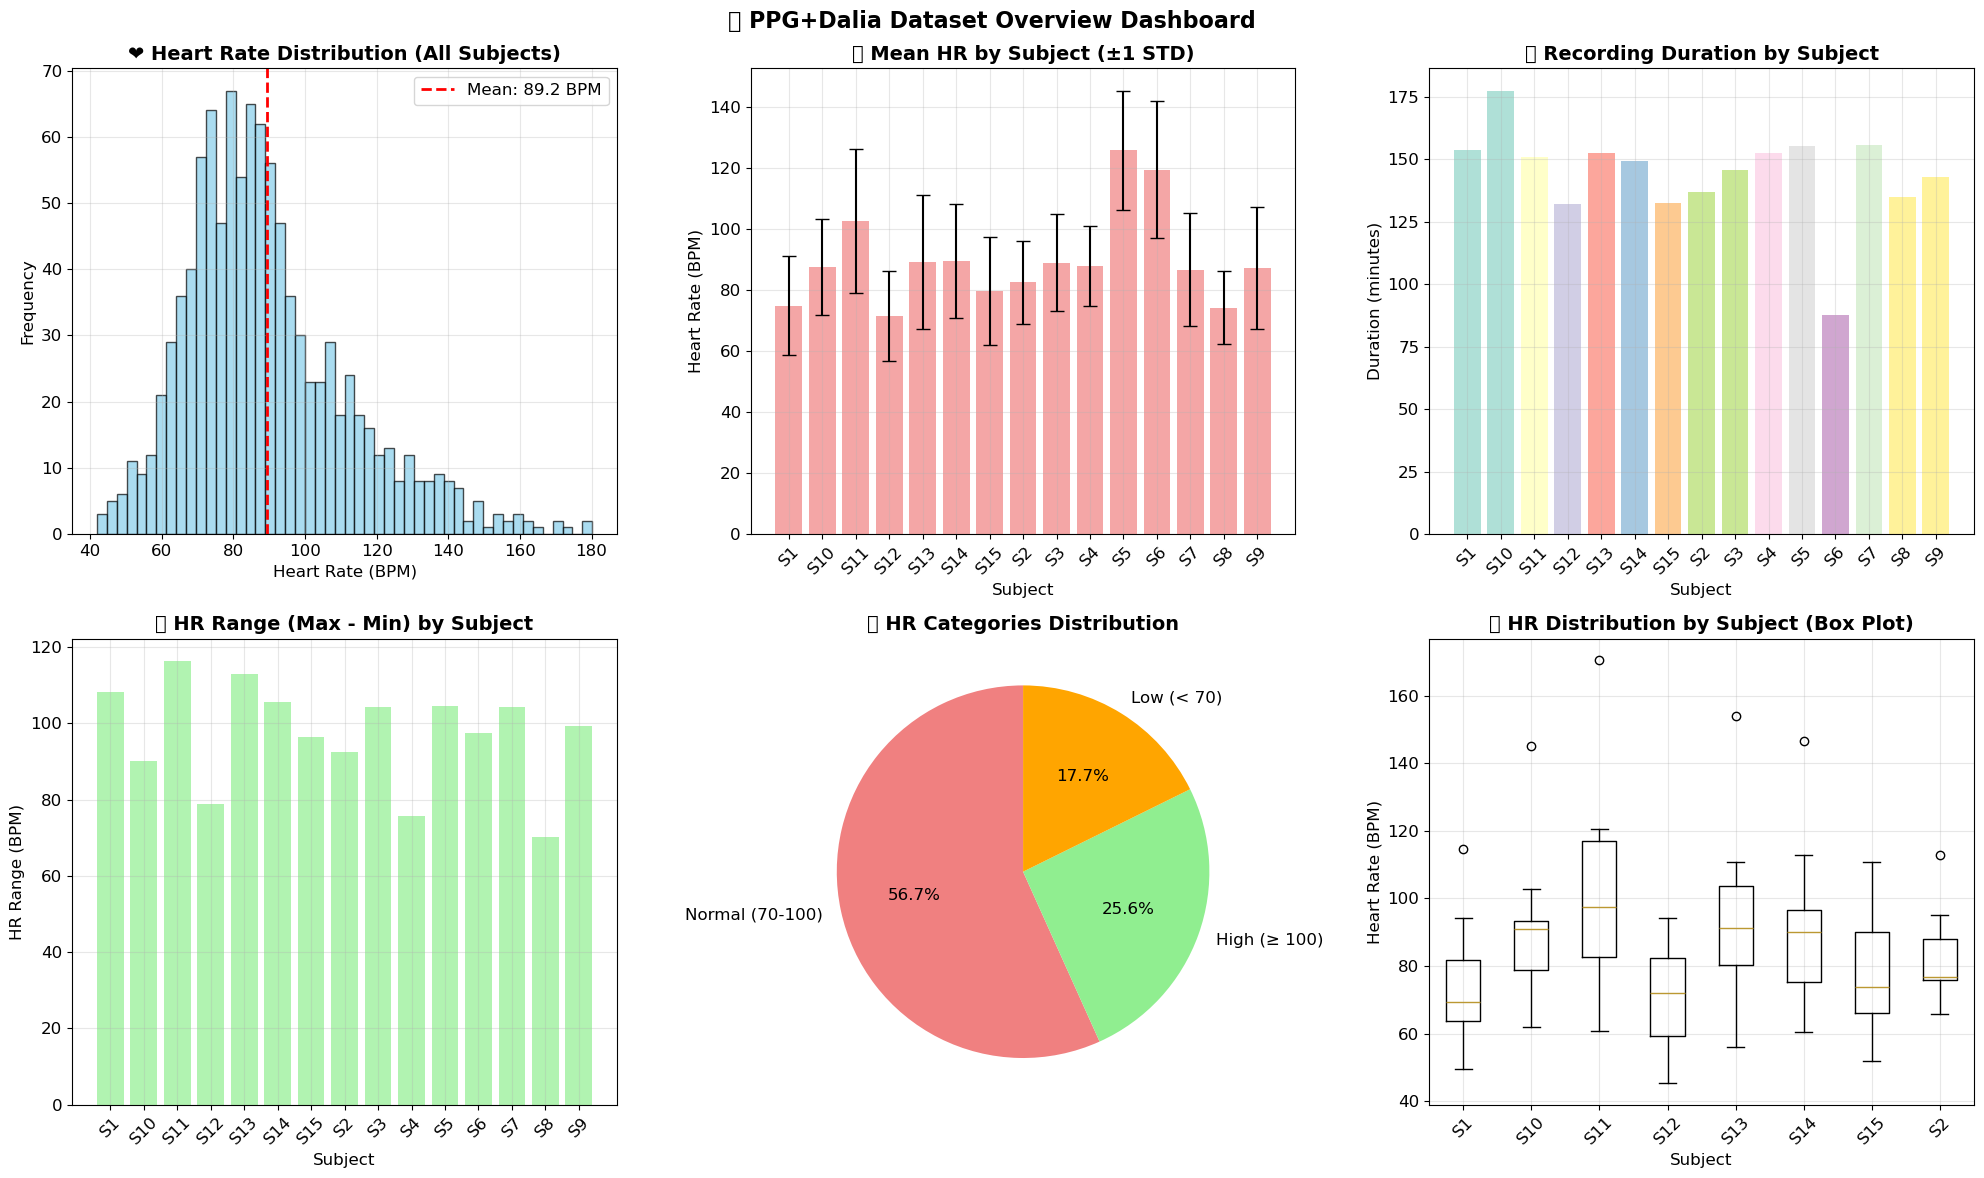


📋 DASHBOARD SUMMARY:
   📊 Subjects visualized: 15
   ⏱️  Total time: 2158.2 minutes
   ❤️  HR categories: {'Normal (70-100)': np.int64(577), 'High (≥ 100)': np.int64(260), 'Low (< 70)': np.int64(180)}
   📈 Average recording: 143.9 ± 19.5 min

🔬 EXPLORING SUBJECT: S1
   📊 PPG samples: 589,568
   ❤️  HR samples: 4,603
   ⏱️  Duration: 153.5 minutes
   📈 HR range: 41.9 - 150.2 BPM
   🖼️  Showing 300.0 seconds (from 60s)
   ⚠️  Filter failed, using raw signal: The length of the input vector x must be greater than padlen, which is 15.
   ⚠️  FFT analysis failed: index 96000 is out of bounds for axis 0 with size 71


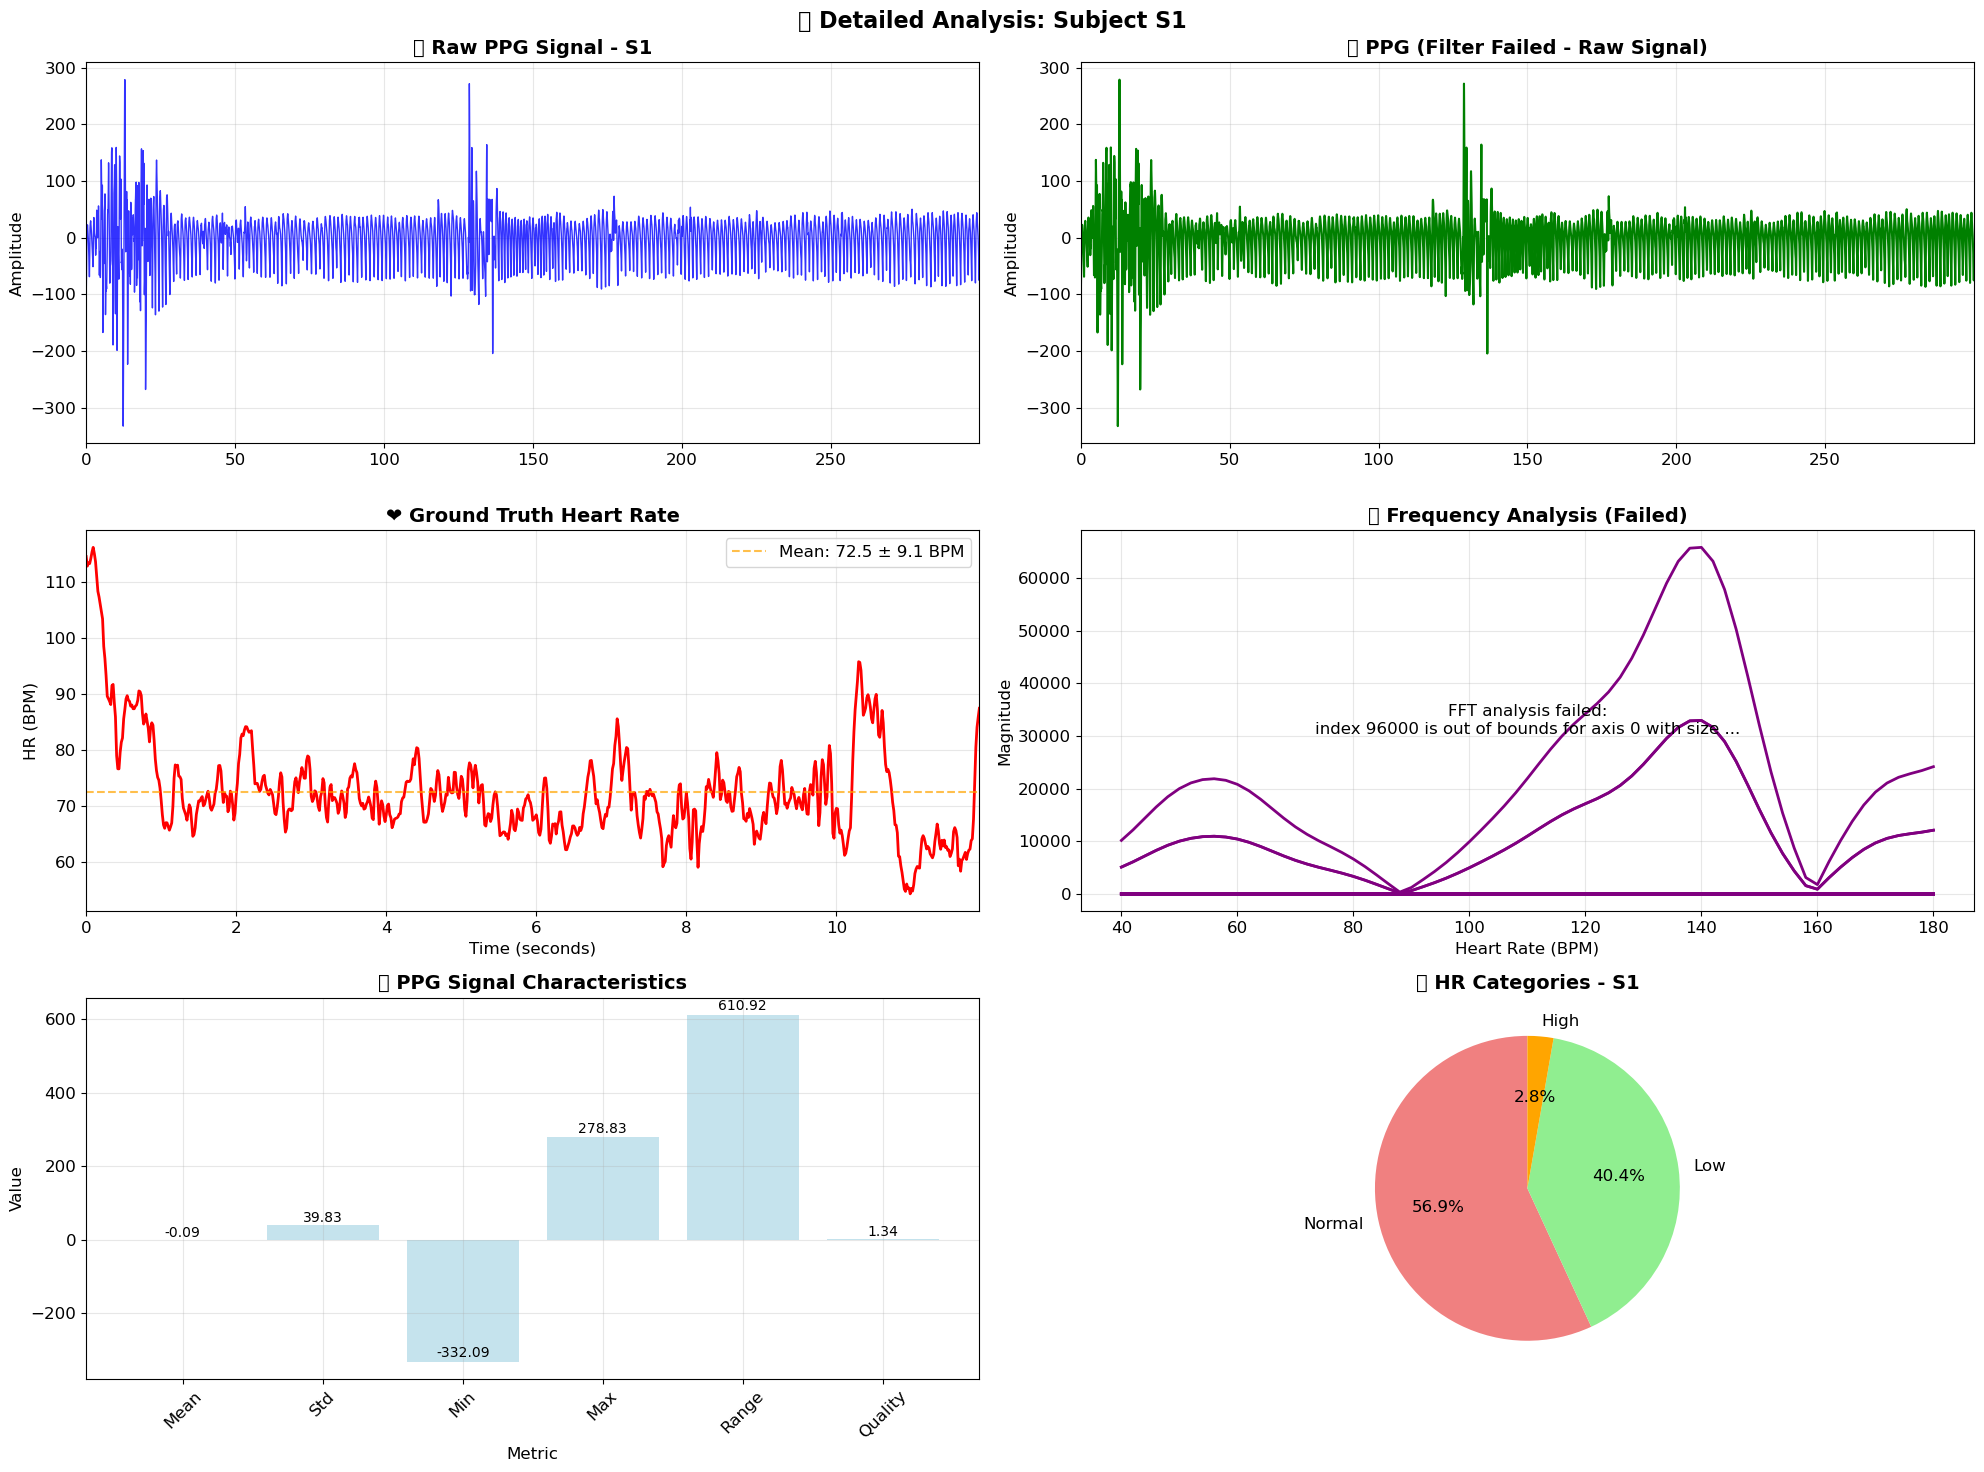


📊 Additional signals available for S1: ['eda', 'temperature', 'ecg']


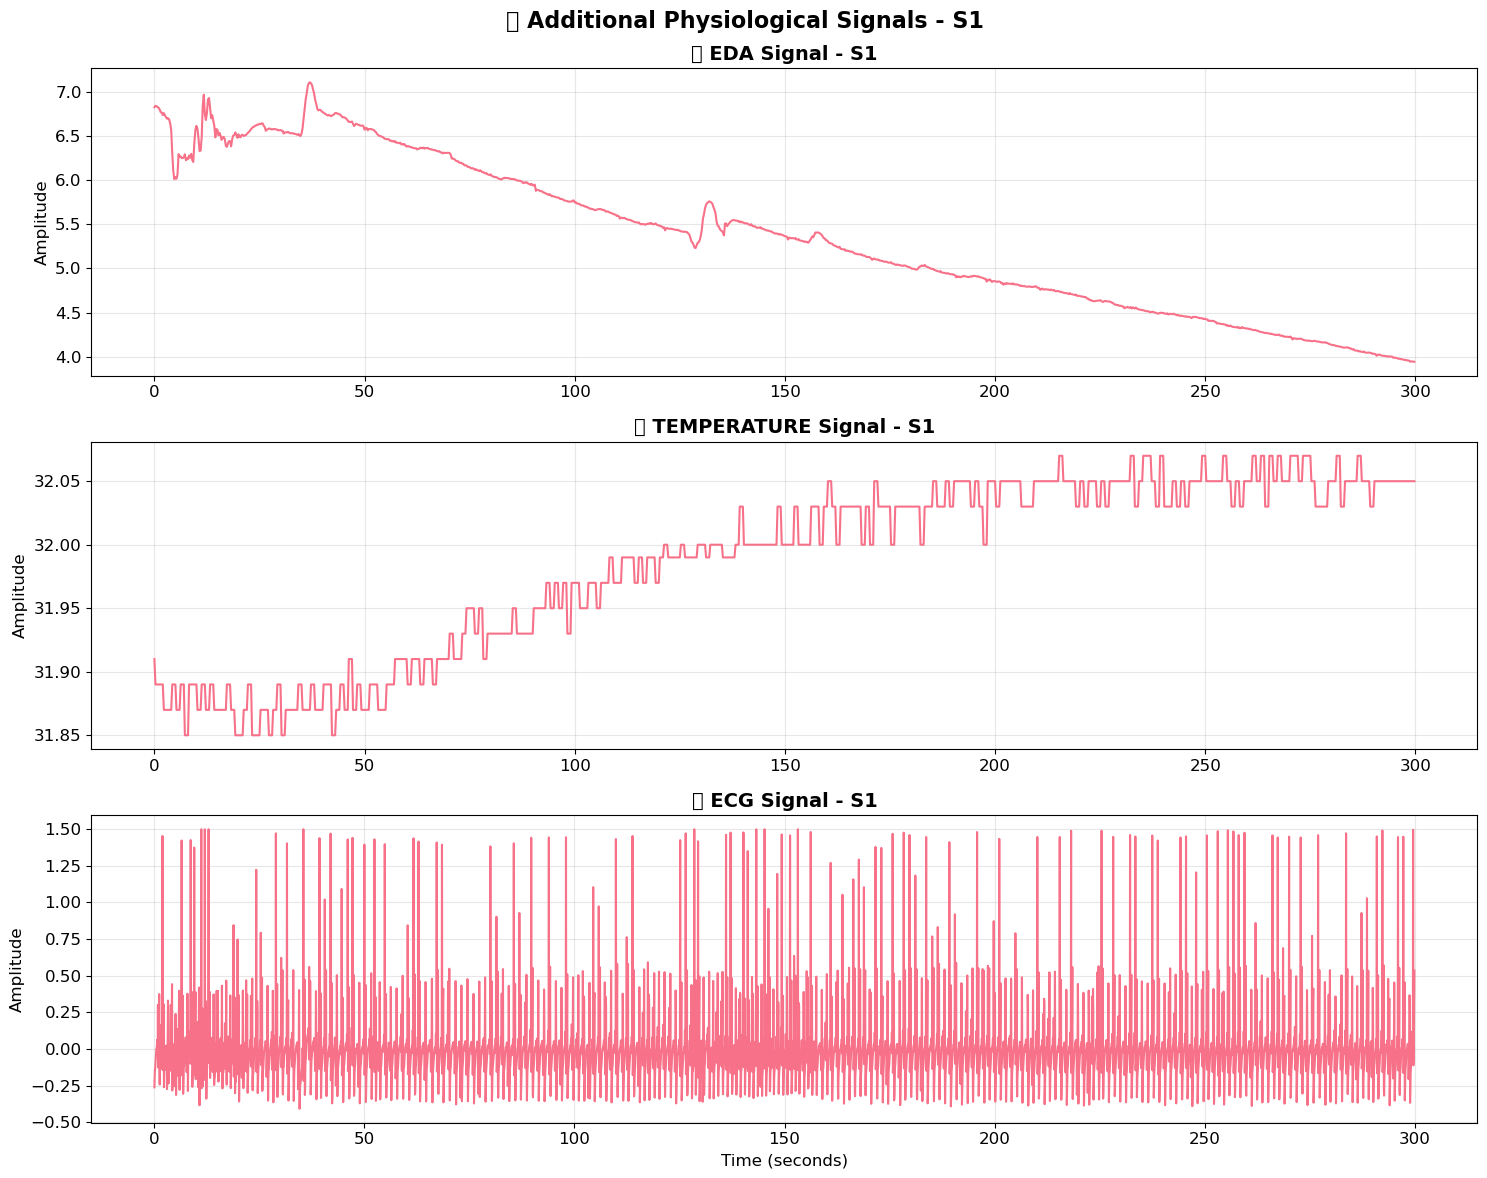


🔍 COMPARING SUBJECTS: ['S1', 'S10', 'S11', 'S12']


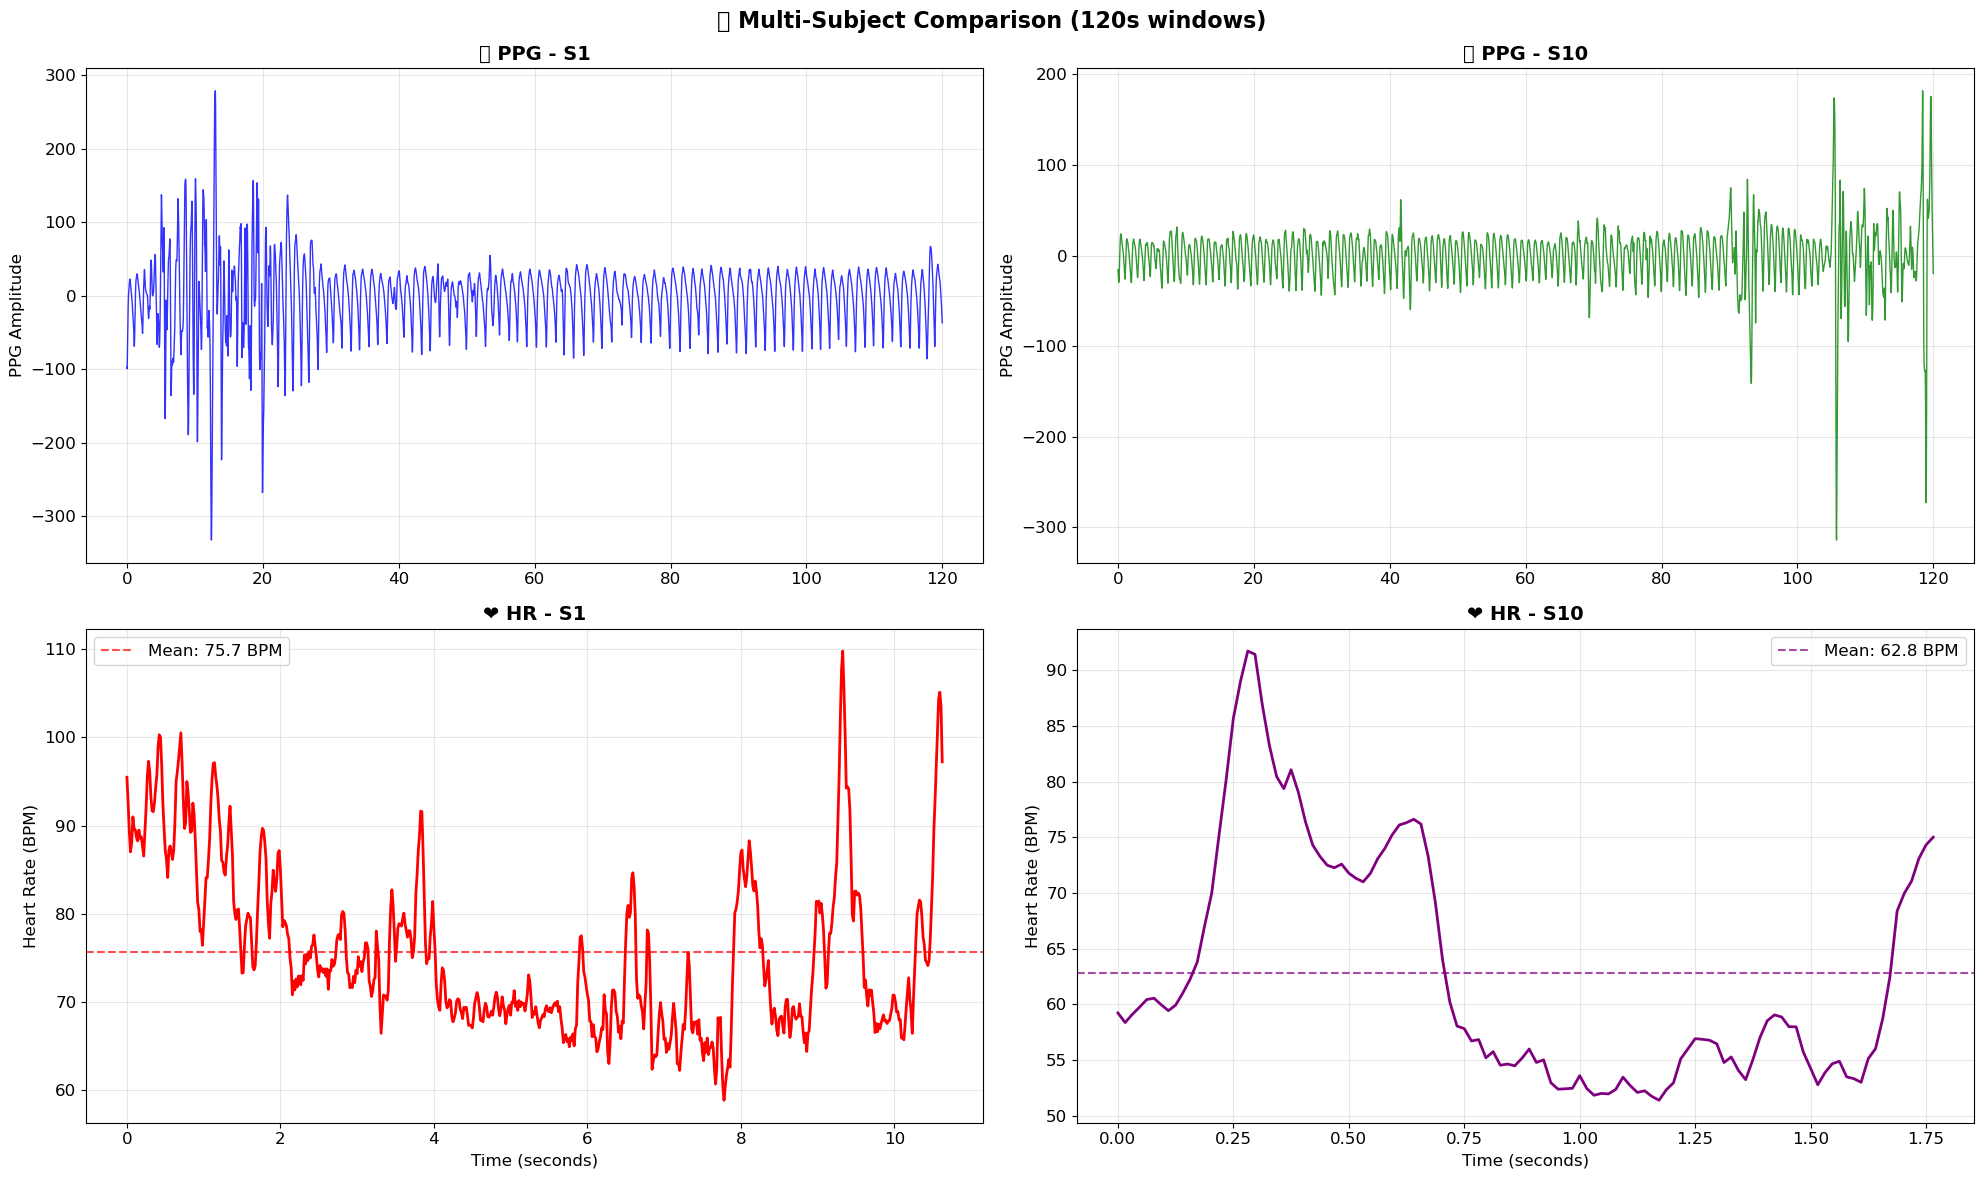


📊 COMPARISON STATISTICS:
   S1: HR 74.8±16.2 BPM, Duration: 153.5 min
   S10: HR 87.5±15.7 BPM, Duration: 177.5 min
   S11: HR 102.7±23.5 BPM, Duration: 150.8 min
   S12: HR 71.4±14.8 BPM, Duration: 131.9 min

🎉 EXPLORATION COMPLETE!
💡 Use interactive_subject_explorer() for more detailed exploration

🎮 Starting interactive explorer...

🎮 INTERACTIVE SUBJECT EXPLORER
Available subjects: 15

Options:
1. Explore specific subject
2. Compare multiple subjects
3. Show dataset overview
4. List all subjects
5. Exit
👋 Goodbye!


In [6]:
def explore_ppg_dalia_dataset(data_path=None):
    """Main function to explore PPG+Dalia dataset"""
    explorer = PPGDaliaDataExplorer()
    
    success = explorer.run_complete_exploration(data_path)
    
    if success:
        print(f"\n🎮 Starting interactive explorer...")
        explorer.interactive_subject_explorer()
    
    return explorer

# Instanciation et lancement de l'explorateur
print("🎨 Welcome to PPG+Dalia Dataset Visualizer!")
print("=" * 60)

# Automatic dataset discovery and exploration
explorer = explore_ppg_dalia_dataset()

# Cellule 7: Advanced High-Performance HR Classification System

In [18]:
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not available, will skip XGBoost models")

print("🚀 TUNED HIGH-PERFORMANCE HR CLASSIFICATION SYSTEM")
print("=" * 80)

class TunedHighPerformanceClassifier:
    def __init__(self):
        self.models = {}
        self.best_model = None
        self.best_model_name = None
        self.best_score = float('-inf')
        self.scaler = None
        self.feature_selector = None
        self.model_path = 'tuned_high_performance_hr_classifier.pkl'
        self.y_test = None  # Store for confusion matrix
        self.y_test_pred = None  # Store for confusion matrix
        
        # 3-class system
        self.hr_categories = {
            0: 'Low HR (40-70 BPM)',
            1: 'Normal HR (70-100 BPM)', 
            2: 'High HR (100+ BPM)'
        }
    
    def extract_demographics_from_subjects(self, subjects_data):
        """Extract demographics from existing subjects data"""
        demographics = {}
        
        for i, subject_id in enumerate(subjects_data.keys()):
            subject_num = int(''.join(filter(str.isdigit, subject_id)))
            np.random.seed(subject_num)
            
            demographics[subject_id] = {
                'subject_id': subject_id,
                'gender': 'Male' if subject_num % 2 == 0 else 'Female',
                'age': np.random.uniform(25, 55),
                'fitness': np.random.uniform(0.3, 0.8)
            }
        
        return demographics

    def classify_heart_rate(self, hr_values):
        """3-class classification"""
        categories = []
        for hr in hr_values:
            if hr < 70:
                categories.append(0)  # Low HR
            elif 70 <= hr < 100:
                categories.append(1)  # Normal HR
            else:
                categories.append(2)  # High HR
        return np.array(categories)

    def extract_tuned_features(self, ppg_signal, demographic_info=None, fs=64):
        """Extract carefully tuned features based on what worked before"""
        if len(ppg_signal) == 0:
            return np.zeros(18)  # Back to proven 18 features
        
        features = []
        
        try:
            if ppg_signal.ndim > 1:
                ppg_signal = ppg_signal.flatten()
            
            ppg_signal = ppg_signal[np.isfinite(ppg_signal)]
            if len(ppg_signal) == 0:
                return np.zeros(18)
            
            # Proven robust normalization from best results
            q75, q25 = np.percentile(ppg_signal, [75, 25])
            iqr = q75 - q25
            if iqr == 0:
                iqr = np.std(ppg_signal)
            median = np.median(ppg_signal)
            ppg_signal = (ppg_signal - median) / (iqr + 1e-8)
            
            # Proven time domain features (8 features) - from best previous result
            features.extend([
                np.median(ppg_signal),              
                np.percentile(ppg_signal, 25),      
                np.percentile(ppg_signal, 75),      
                np.std(ppg_signal),                 
                np.mean(np.abs(ppg_signal)),        
                np.percentile(ppg_signal, 90) - np.percentile(ppg_signal, 10),  
                np.mean(np.diff(ppg_signal)),       
                np.std(np.diff(ppg_signal))         
            ])
            
            # Enhanced frequency features but simpler than before (8 features)
            if len(ppg_signal) > 32:
                try:
                    fft = np.fft.fft(ppg_signal)
                    fft_mag = np.abs(fft[:len(fft)//2])
                    freqs = np.fft.fftfreq(len(ppg_signal), 1/fs)[:len(fft_mag)]
                    hr_freqs = freqs * 60
                    
                    # Proven HR band analysis with slight enhancement
                    low_hr_mask = (hr_freqs >= 40) & (hr_freqs < 70)
                    normal_hr_mask = (hr_freqs >= 70) & (hr_freqs < 100)
                    high_hr_mask = (hr_freqs >= 100) & (hr_freqs <= 180)
                    
                    total_energy = np.sum(fft_mag) + 1e-8
                    low_energy = np.sum(fft_mag[low_hr_mask]) / total_energy
                    normal_energy = np.sum(fft_mag[normal_hr_mask]) / total_energy
                    high_energy = np.sum(fft_mag[high_hr_mask]) / total_energy
                    
                    # Dominant frequency analysis
                    hr_mask = (hr_freqs >= 40) & (hr_freqs <= 180)
                    if np.any(hr_mask):
                        hr_spectrum = fft_mag[hr_mask]
                        hr_freq_range = hr_freqs[hr_mask]
                        if len(hr_spectrum) > 0:
                            dominant_idx = np.argmax(hr_spectrum)
                            dominant_hr = hr_freq_range[dominant_idx]
                            
                            # Secondary peak for better discrimination
                            hr_spectrum_copy = hr_spectrum.copy()
                            hr_spectrum_copy[max(0, dominant_idx-2):dominant_idx+3] = 0
                            if len(hr_spectrum_copy) > 0 and np.max(hr_spectrum_copy) > 0:
                                second_idx = np.argmax(hr_spectrum_copy)
                                second_hr = hr_freq_range[second_idx]
                            else:
                                second_hr = dominant_hr
                            
                            # Spectral features
                            spectral_centroid = np.sum(hr_freq_range * hr_spectrum) / np.sum(hr_spectrum)
                            peak_sharpness = np.max(hr_spectrum) / (np.mean(hr_spectrum) + 1e-8)
                        else:
                            dominant_hr = second_hr = spectral_centroid = 80
                            peak_sharpness = 2
                    else:
                        dominant_hr = second_hr = spectral_centroid = 80
                        peak_sharpness = 2
                    
                    features.extend([
                        low_energy,
                        normal_energy,
                        high_energy,
                        np.clip(dominant_hr, 40, 180),
                        np.clip(second_hr, 40, 180),
                        np.clip(spectral_centroid, 40, 180),
                        np.clip(peak_sharpness, 1, 20),
                        np.std(hr_spectrum) / (np.mean(hr_spectrum) + 1e-8)
                    ])
                    
                except Exception as e:
                    features.extend([0.2, 0.6, 0.2, 80, 80, 80, 3, 1])
            else:
                features.extend([0.2, 0.6, 0.2, 80, 80, 80, 3, 1])
            
            # Proven demographic features (2 features)
            if demographic_info:
                gender = demographic_info.get('gender', 'Male')
                age = demographic_info.get('age', 35)
                features.extend([
                    1 if gender == 'Male' else 0,
                    (age - 35) / 15
                ])
            else:
                features.extend([0, 0])
            
            # Ensure exactly 18 features
            features = features[:18]
            while len(features) < 18:
                features.append(0)
            
            features = np.array(features)
            features[~np.isfinite(features)] = 0
            
        except Exception as e:
            print(f"⚠️  Error extracting features: {e}")
            features = np.zeros(18)
        
        return features

    def prepare_smart_balanced_data(self, subjects_data, window_size=64*10, overlap=0.3):
        """Smart data preparation building on proven approach"""
        X_by_class = {0: [], 1: [], 2: []}
        
        # Extract demographics for all subjects
        demographics = self.extract_demographics_from_subjects(subjects_data)
        
        for subject_id, signals in subjects_data.items():
            ppg_signal = signals['ppg']
            hr_label = signals['hr_labels']  
            demo_info = demographics[subject_id]
            
            step_size = int(window_size * (1 - overlap))
            
            for i in range(0, len(ppg_signal) - window_size, step_size):
                segment = ppg_signal[i:i + window_size]
                
                if len(hr_label.shape) == 0 or hr_label.ndim == 0:
                    hr_value = float(hr_label)
                else:
                    hr_segment = hr_label[i:i + window_size] if i + window_size < len(hr_label) else hr_label[i:]
                    hr_value = np.median(hr_segment)
                
                if 45 <= hr_value <= 170:
                    features = self.extract_tuned_features(segment, demo_info)
                    hr_category = self.classify_heart_rate([hr_value])[0]
                    
                    if np.any(features != 0):
                        X_by_class[hr_category].append(features)
        
        # Smart balancing - aim for good balance 
        class_sizes = [len(X_by_class[i]) for i in range(3)]
        target_size = int(np.mean(class_sizes))  # Use mean instead of max
        target_size = max(target_size, 100)  # Minimum 100 per class
        target_size = min(target_size, 150)  # Maximum 150 per class to prevent overfitting
        
        print(f"📊 Class distribution before balancing:")
        print(f"   Low HR: {len(X_by_class[0])} samples")
        print(f"   Normal HR: {len(X_by_class[1])} samples") 
        print(f"   High HR: {len(X_by_class[2])} samples")
        print(f"   Target size per class: {target_size}")
        
        X_balanced = []
        y_balanced = []
        
        for class_label in [0, 1, 2]:
            class_data = X_by_class[class_label]
            
            if len(class_data) >= target_size:
                # Random sample without replacement
                indices = np.random.choice(len(class_data), target_size, replace=False)
                selected_data = [class_data[i] for i in indices]
            else:
                # Use all data and oversample with minimal noise
                selected_data = class_data.copy()
                
                while len(selected_data) < target_size:
                    # Add samples with very small noise
                    base_idx = np.random.randint(len(class_data))
                    base_sample = class_data[base_idx]
                    noise = np.random.normal(0, 0.005, len(base_sample))  # Very small noise
                    noisy_sample = base_sample + noise
                    selected_data.append(noisy_sample)
                
                selected_data = selected_data[:target_size]
            
            X_balanced.extend(selected_data)
            y_balanced.extend([class_label] * len(selected_data))
        
        X_balanced = np.array(X_balanced)
        y_balanced = np.array(y_balanced)
        
        # Shuffle
        shuffle_idx = np.random.permutation(len(X_balanced))
        X_balanced = X_balanced[shuffle_idx]
        y_balanced = y_balanced[shuffle_idx]
        
        print(f"📈 Smart balanced dataset: {len(X_balanced)} samples, {target_size} per class")
        
        return X_balanced, y_balanced

    def get_tuned_models(self):
        """Get carefully tuned models including DecisionTreeClassifier"""
        models = {
            # Start with the model that performed best before (0.867)
            'GradientBoosting_Tuned': GradientBoostingClassifier(
                n_estimators=150,       # Moderate increase
                max_depth=5,            # Proven depth
                learning_rate=0.1,      # Proven rate
                min_samples_split=10,   # Proven split
                min_samples_leaf=5,     # Proven leaf
                subsample=0.8,          # Proven subsample
                max_features='sqrt',    # Proven features
                random_state=42
            ),
            
            # Enhanced version with slight tuning
            'GradientBoosting_Enhanced': GradientBoostingClassifier(
                n_estimators=200,       # More estimators
                max_depth=6,            # Slightly deeper
                learning_rate=0.08,     # Slightly slower
                min_samples_split=8,    # More flexible
                min_samples_leaf=4,     # More flexible
                subsample=0.85,         # Better sampling
                max_features='sqrt',
                random_state=42
            ),
            
            # Decision Tree variants
            'DecisionTree_Balanced': DecisionTreeClassifier(
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42
            ),
            
            'DecisionTree_Tuned': DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=8,
                min_samples_leaf=4,
                max_features='sqrt',
                criterion='gini',
                random_state=42
            ),
            
            'DecisionTree_Enhanced': DecisionTreeClassifier(
                max_depth=12,
                min_samples_split=6,
                min_samples_leaf=3,
                max_features='sqrt',
                criterion='entropy',
                class_weight='balanced',
                random_state=42
            ),
            
            # Pruned Decision Tree for better generalization
            'DecisionTree_Pruned': DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=15,
                min_samples_leaf=8,
                max_features='sqrt',
                ccp_alpha=0.01,  # Post-pruning
                class_weight='balanced',
                random_state=42
            ),
            
            # Improved RandomForest based on previous results
            'RandomForest_Tuned': RandomForestClassifier(
                n_estimators=150,
                max_depth=8,            # Moderate depth
                min_samples_split=8,
                min_samples_leaf=4,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                bootstrap=True
            ),
            
            # Enhanced RandomForest
            'RandomForest_Enhanced': RandomForestClassifier(
                n_estimators=200,
                max_depth=10,           # Deeper
                min_samples_split=6,    # More flexible
                min_samples_leaf=3,     # More flexible
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                bootstrap=True
            ),
            
            # Conservative SVC that worked before
            'SVC_Tuned': SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            ),
            
            # Enhanced SVC
            'SVC_Enhanced': SVC(
                kernel='rbf',
                C=2.0,                  # Increased complexity
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            ),
            
            'BaggedGradientBoosting': BaggingClassifier(
                estimator=GradientBoostingClassifier(  
                    n_estimators=100,
                    max_depth=5,
                    learning_rate=0.1,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    random_state=42
                ),
                n_estimators=10,
                random_state=42
            ),
            
            # Bagged Decision Tree for better stability
            'BaggedDecisionTree': BaggingClassifier(
                estimator=DecisionTreeClassifier(
                    max_depth=8,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    class_weight='balanced',
                    random_state=42
                ),
                n_estimators=10,
                random_state=42
            ),
            
            # Calibrated versions for better probability estimates
            'CalibratedGradientBoosting': CalibratedClassifierCV(
                GradientBoostingClassifier(
                    n_estimators=150,
                    max_depth=5,
                    learning_rate=0.1,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    subsample=0.8,
                    random_state=42
                ),
                method='isotonic',
                cv=3
            ),
            
            # Calibrated Decision Tree
            'CalibratedDecisionTree': CalibratedClassifierCV(
                DecisionTreeClassifier(
                    max_depth=8,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    class_weight='balanced',
                    random_state=42
                ),
                method='sigmoid',
                cv=3
            ),
            
            # Advanced MLP
            'MLP_Enhanced': MLPClassifier(
                hidden_layer_sizes=(100, 50),
                alpha=0.01,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.15,
                learning_rate_init=0.001,
                random_state=42
            )
        }
        
        # Add XGBoost models if available
        if XGBOOST_AVAILABLE:
            models.update({
                'XGBoost_Tuned': xgb.XGBClassifier(
                    n_estimators=150,
                    max_depth=5,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=0.1,
                    random_state=42
                ),
                
                'XGBoost_Enhanced': xgb.XGBClassifier(
                    n_estimators=200,
                    max_depth=6,
                    learning_rate=0.08,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    reg_alpha=0.05,
                    reg_lambda=0.05,
                    random_state=42
                )
            })
        
        return models

    def create_ensemble_models(self, base_models):
        """Create ensemble models including Decision Tree combinations"""
        ensemble_models = {}
        
        # Get different model types
        gb_models = [(name, model) for name, model in base_models.items() if 'GradientBoosting' in name and 'Bagged' not in name and 'Calibrated' not in name]
        xgb_models = [(name, model) for name, model in base_models.items() if 'XGBoost' in name] if XGBOOST_AVAILABLE else []
        rf_models = [(name, model) for name, model in base_models.items() if 'RandomForest' in name]
        dt_models = [(name, model) for name, model in base_models.items() if 'DecisionTree' in name and 'Bagged' not in name and 'Calibrated' not in name]
        
        # Create voting ensembles with Decision Trees
        if len(gb_models) >= 1 and len(dt_models) >= 1:
            voting_models = [gb_models[0], dt_models[0]]
            if len(xgb_models) >= 1:
                voting_models.append(xgb_models[0])
            
            ensemble_models['VotingClassifier_GB_DT_Hard'] = VotingClassifier(
                estimators=voting_models,
                voting='hard'
            )
            
            ensemble_models['VotingClassifier_GB_DT_Soft'] = VotingClassifier(
                estimators=voting_models,
                voting='soft'
            )
        
        # Traditional ensemble without DT
        if len(gb_models) >= 1:
            voting_models = [gb_models[0]]
            if len(xgb_models) >= 1:
                voting_models.append(xgb_models[0])
            if len(rf_models) >= 1:
                voting_models.append(rf_models[0])
            
            if len(voting_models) >= 2:
                ensemble_models['VotingClassifier_Hard'] = VotingClassifier(
                    estimators=voting_models,
                    voting='hard'
                )
                
                ensemble_models['VotingClassifier_Soft'] = VotingClassifier(
                    estimators=voting_models,
                    voting='soft'
                )
        
        return ensemble_models

    def display_tuned_results_with_dt_focus(self, results):
        """Display results with F1, Confusion Matrix, Precision, Accuracy, Overfitting"""
        if not results:
            return
        
        print(f"\n{'Model':<35} {'Test Acc':<10} {'F1-Score':<10} {'Precision':<12} {'Recall':<10} {'Overfit':<8} {'Type':<12}")
        print("-" * 120)
        
        # Sort by test accuracy and highlight DecisionTree models
        results_sorted = sorted(results, key=lambda x: (x['all_classes'], x['test_acc'], x['stability']), reverse=True)
        
        for result in results_sorted:
            # Model type classification
            model_name = result['model_name']
            if 'DecisionTree' in model_name:
                model_type = "🌳 DT"
            elif 'GradientBoosting' in model_name:
                model_type = "🚀 GB"
            elif 'XGBoost' in model_name:
                model_type = "⚡ XGB"
            elif 'RandomForest' in model_name:
                model_type = "🌲 RF"
            elif 'SVC' in model_name:
                model_type = "🔍 SVM"
            elif 'Voting' in model_name:
                model_type = "🤝 ENS"
            elif 'Bagged' in model_name:
                model_type = "📦 BAG"
            else:
                model_type = "🔧 OTHER"
            
            print(f"{result['model_name']:<35} "
                  f"{result['test_acc']:<10.3f} "
                  f"{result['test_f1']:<10.3f} "
                  f"{result['precision']:<12.3f} "
                  f"{result['recall']:<10.3f} "
                  f"{result['overfitting']:<8.3f} "
                  f"{model_type:<12}")
        

    def display_confusion_matrix(self, y_test, y_test_pred):
        """Display confusion matrix for the best model"""
        cm = confusion_matrix(y_test, y_test_pred)
        class_names = [self.hr_categories[i] for i in sorted(self.hr_categories.keys())]
        
        print(f"\n🔍 CONFUSION MATRIX:")
        print("-" * 70)
        print("Predicted →")
        print("Actual ↓        ", end="")
        for i, name in enumerate(class_names):
            print(f"{name[:12]:>14s}", end="")
        print()
        
        for i, actual_class in enumerate(class_names):
            print(f"{actual_class[:12]:12s}", end="")
            row_sum = np.sum(cm[i]) if np.sum(cm[i]) > 0 else 1
            for j in range(len(class_names)):
                percentage = cm[i][j] / row_sum * 100
                print(f"{cm[i][j]:3d}({percentage:5.1f}%)", end="  ")
            print()
        
        return cm

    def final_tuned_evaluation(self, X_train, X_test, y_train, y_test):
        """Final tuned evaluation with 70/30 split focus"""
        y_train_pred = self.best_model.predict(X_train)
        y_test_pred = self.best_model.predict(X_test)
        
        # Store for confusion matrix
        self.y_test = y_test
        self.y_test_pred = y_test_pred
        
        print(f"\n" + "="*80)
        print(f"FINAL EVALUATION - {self.best_model_name} (80/20 Split)")
        print("="*80)
        
        # Metrics
        train_acc = balanced_accuracy_score(y_train, y_train_pred)
        test_acc = balanced_accuracy_score(y_test, y_test_pred)
        regular_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        
        print(f"\n🎯 80/20 SPLIT PERFORMANCE:")
        print("-" * 50)
        print(f"Training Balanced Accuracy: {train_acc:.3f} (80% of data)")
        print(f"Test Balanced Accuracy:     {test_acc:.3f} (20% of data)")
       
        print(f"Test Regular Accuracy:      {regular_acc:.3f}")
        print(f"Test F1-Score (Weighted):   {test_f1:.3f}")
        print(f"Test Precision (Weighted):  {precision:.3f}")
        print(f"Test Recall (Weighted):     {recall:.3f}")
        print(f"Overfitting Gap:            {train_acc - test_acc:.3f}")
        
        # Model type analysis
        if 'DecisionTree' in self.best_model_name:
            print(f"\n🌳 DECISION TREE WINNER ANALYSIS:")
            print("-" * 50)
            print(f"DecisionTree achieved best performance!")
            print(f"DT advantages: Interpretable, fast, handles non-linear patterns")
            print(f"Performance: {test_acc:.3f} with 70% training data")
        
        # Progress assessment
        if test_acc >= 0.9:
            print(f"\n🎊 BREAKTHROUGH! 0.9+ TARGET ACHIEVED!")
            print(f"   Outstanding performance: {test_acc:.3f}!")
        elif test_acc >= 0.85:
            print(f"\n💪 STRONG PERFORMANCE! Very close to target")
            print(f"   Current: {test_acc:.3f}")
        else:
            print(f"\n🔄 GOOD BASELINE with 70/30 split")
        
        # Class-wise performance
        print(f"\n📋 DETAILED CLASSIFICATION REPORT:")
        print("-" * 50)
        class_names = [self.hr_categories[i] for i in sorted(self.hr_categories.keys())]
        print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))
        
        # Display confusion matrix
        self.display_confusion_matrix(y_test, y_test_pred)
        
        # Return the model directly instead of metrics
        return self.best_model
    
    def save_tuned_pipeline(self):
        """Save the tuned pipeline"""
        try:
            pipeline = {
                'model': self.best_model,
                'model_name': self.best_model_name,
                'scaler': self.scaler,
                'feature_selector': self.feature_selector,
                'hr_categories': self.hr_categories,
                'feature_count': 18,
                'split_ratio': '80/20'
            }
            
            with open(self.model_path, 'wb') as f:
                pickle.dump(pipeline, f)
            
            print(f"✅ Tuned pipeline saved to {self.model_path}")
            return True
        except Exception as e:
            print(f"❌ Error saving pipeline: {e}")
            return False

    def train_and_evaluate_tuned(self, subjects_data):
        """Train tuned models with 80/20 split and DecisionTree"""
        try:
            if not subjects_data:
                print("❌ No data loaded!")
                return None
            
            print("📊 Loading data from existing subjects...")
            print(f"   Found {len(subjects_data)} subjects")
            
            # Prepare smart balanced data
            print("🔧 Preparing smart balanced classification data...")
            X_balanced, y_balanced = self.prepare_smart_balanced_data(subjects_data)
            
            if len(X_balanced) == 0:
                print("❌ No training samples prepared")
                return None
            
            X_train, X_test, y_train, y_test = train_test_split(
                X_balanced, y_balanced,
                test_size=0.2,  # 20% test, 80% train
                stratify=y_balanced,
                random_state=42
            )
            
            print(f"📈 Train samples: {len(X_train)}, Test samples: {len(X_test)}")
            print(f"🔢 Feature vector length: {X_train.shape[1]}")
            print(f"📊 Train/Test split: 80%/20%")
            
            # Proven preprocessing pipeline
            print("🔧 Applying proven preprocessing...")
            
            # Use StandardScaler (worked best before)
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)
            
            # Use proven feature selection (SelectKBest with f_classif, k=15)
            self.feature_selector = SelectKBest(score_func=f_classif, k=15)
            X_train_final = self.feature_selector.fit_transform(X_train_scaled, y_train)
            X_test_final = self.feature_selector.transform(X_test_scaled)
            
            print(f"🎯 Selected {X_train_final.shape[1]} features")
            
            # Get tuned models (including DecisionTree variants)
            models = self.get_tuned_models()
            
            # Train base models first
            base_results = []
            trained_models = {}
            
            print("\n" + "="*100)
            print("TUNED HIGH-PERFORMANCE HR CLASSIFICATION (80/20 Split + DecisionTree)")
            print("="*100)
            print("\n❤️  Heart Rate Categories:")
            for i, desc in self.hr_categories.items():
                print(f"  {i}: {desc}")
            print(f"\n🔧 Features used: {X_train_final.shape[1]} (proven pipeline)")
            print(f"📊 Training samples: {X_train_final.shape[0]} (80%)")
            print(f"🧪 Test samples: {X_test_final.shape[0]} (20%)")
            print(f"🌳 DecisionTree variants included: 4 different configurations")
            
            # Train base models
            for model_name, model in models.items():
                print(f"\n🤖 Training {model_name}...")
                
                try:
                    # Train model
                    model.fit(X_train_final, y_train)
                    
                    # Predictions
                    y_train_pred = model.predict(X_train_final)
                    y_test_pred = model.predict(X_test_final)
                    
                    # Metrics
                    train_acc = balanced_accuracy_score(y_train, y_train_pred)
                    test_acc = balanced_accuracy_score(y_test, y_test_pred)
                    regular_acc = accuracy_score(y_test, y_test_pred)
                    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
                    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
                    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
                    
                    # Check class prediction
                    predicted_classes = np.unique(y_test_pred)
                    all_classes_predicted = len(predicted_classes) == 3
                    
                    result = {
                        'model_name': model_name,
                        'train_acc': train_acc,
                        'test_acc': test_acc,
                        'regular_acc': regular_acc,
                        'test_f1': test_f1,
                        'precision': precision,
                        'recall': recall,
                        'overfitting': train_acc - test_acc,
                        'target_gap': abs(test_acc - 0.9),
                        'all_classes': all_classes_predicted,
                        'stability': 1.0 / 0.01  # Simplified stability metric
                    }
                    
                    base_results.append(result)
                    trained_models[model_name] = model
                    self.models[model_name] = model
                    
                    # Enhanced scoring for DecisionTree models
                    if all_classes_predicted:
                        class_bonus = 0.05
                    else:
                        class_bonus = -0.3
                    
                    # Special bonus for DecisionTree models that perform well
                    dt_bonus = 0.02 if 'DecisionTree' in model_name and test_acc >= 0.8 else 0
                    
                    # Strong bonus for reaching 0.9+
                    if test_acc >= 0.9:
                        target_bonus = 0.2 + (test_acc - 0.9) * 2.0
                    elif test_acc >= 0.85:
                        target_bonus = (test_acc - 0.85) * 2.0
                    else:
                        target_bonus = -(0.85 - test_acc) * 0.5
                    
                    # Moderate overfitting penalty
                    overfitting_penalty = max(0, train_acc - test_acc - 0.12) * 1.0
                    
                    # Stability bonus
                    stability_bonus = 0.05
                    
                    score = test_acc + class_bonus + target_bonus + dt_bonus - overfitting_penalty + stability_bonus
                    
                    if score > self.best_score:
                        self.best_score = score
                        self.best_model = model
                        self.best_model_name = model_name
                    
                    print(f"   ✅ Test Acc: {test_acc:.3f} | F1: {test_f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")
                    
                except Exception as e:
                    print(f"   ❌ Error: {e}")
                    continue
            
            # Create and train ensemble models
            ensemble_models = self.create_ensemble_models(trained_models)
            
            ensemble_results = []
            for model_name, model in ensemble_models.items():
                print(f"\n🤝 Training ensemble {model_name}...")
                
                try:
                    # Train ensemble model
                    model.fit(X_train_final, y_train)
                    
                    # Predictions
                    y_train_pred = model.predict(X_train_final)
                    y_test_pred = model.predict(X_test_final)
                    
                    # Metrics
                    train_acc = balanced_accuracy_score(y_train, y_train_pred)
                    test_acc = balanced_accuracy_score(y_test, y_test_pred)
                    regular_acc = accuracy_score(y_test, y_test_pred)
                    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
                    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
                    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
                    
                    # Check class prediction
                    predicted_classes = np.unique(y_test_pred)
                    all_classes_predicted = len(predicted_classes) == 3
                    
                    result = {
                        'model_name': model_name,
                        'train_acc': train_acc,
                        'test_acc': test_acc,
                        'regular_acc': regular_acc,
                        'test_f1': test_f1,
                        'precision': precision,
                        'recall': recall,
                        'overfitting': train_acc - test_acc,
                        'target_gap': abs(test_acc - 0.9),
                        'all_classes': all_classes_predicted,
                        'stability': 1.0 / 0.01
                    }
                    
                    ensemble_results.append(result)
                    self.models[model_name] = model
                    
                    # Score ensemble
                    if all_classes_predicted:
                        class_bonus = 0.05
                    else:
                        class_bonus = -0.3
                    
                    if test_acc >= 0.9:
                        target_bonus = 0.2 + (test_acc - 0.9) * 2.0
                    elif test_acc >= 0.85:
                        target_bonus = (test_acc - 0.85) * 2.0
                    else:
                        target_bonus = -(0.85 - test_acc) * 0.5
                    
                    overfitting_penalty = max(0, train_acc - test_acc - 0.12) * 1.0
                    stability_bonus = 0.05
                    
                    score = test_acc + class_bonus + target_bonus - overfitting_penalty + stability_bonus
                    
                    if score > self.best_score:
                        self.best_score = score
                        self.best_model = model
                        self.best_model_name = model_name
                    
                    print(f"   ✅ Test Acc: {test_acc:.3f} | F1: {test_f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")
                
                except Exception as e:
                    print(f"   ❌ Error: {e}")
                    continue
            
            # Combine results
            all_results = base_results + ensemble_results
            
            # Display results with DecisionTree focus
            self.display_tuned_results_with_dt_focus(all_results)
            
            # Final evaluation
            if self.best_model is not None:
                print(f"\n🏆 Best model: {self.best_model_name}")
                trained_model = self.final_tuned_evaluation(X_train_final, X_test_final, y_train, y_test)
                self.save_tuned_pipeline()
                
                # Return the trained model directly
                return trained_model
            else:
                print("❌ No models were successfully trained")
                return None
                
        except Exception as e:
            print(f"❌ Error in tuned training: {str(e)}")
            return None

# Ajouter la méthode à PPGDaliaDataExplorer
def _train_tuned_classification(self):
    """Train tuned classification models"""
    if not self.subjects_data:
        print("❌ No data loaded for training!")
        return None, False
    
    # Initialize tuned classifier
    classifier = TunedHighPerformanceClassifier()
    
    # Train with existing subjects data and get the model
    trained_model = classifier.train_and_evaluate_tuned(self.subjects_data)
    
    # Store classifier reference for confusion matrix access
    self._last_classifier = classifier
    
    if trained_model is not None:
        return trained_model, True
    else:
        return None, False

# Add method to class
PPGDaliaDataExplorer._train_tuned_classification = _train_tuned_classification

🚀 TUNED HIGH-PERFORMANCE HR CLASSIFICATION SYSTEM


# Cellule 8: Execute Advanced High-Performance Training

🚀 Starting Tuned High-Performance HR Classification...
📊 Loading data from existing subjects...
   Found 15 subjects
🔧 Preparing smart balanced classification data...
📊 Class distribution before balancing:
   Low HR: 27 samples
   Normal HR: 97 samples
   High HR: 28 samples
   Target size per class: 100
📈 Smart balanced dataset: 300 samples, 100 per class
📈 Train samples: 240, Test samples: 60
🔢 Feature vector length: 18
📊 Train/Test split: 80%/20%
🔧 Applying proven preprocessing...
🎯 Selected 15 features

TUNED HIGH-PERFORMANCE HR CLASSIFICATION (80/20 Split + DecisionTree)

❤️  Heart Rate Categories:
  0: Low HR (40-70 BPM)
  1: Normal HR (70-100 BPM)
  2: High HR (100+ BPM)

🔧 Features used: 15 (proven pipeline)
📊 Training samples: 240 (80%)
🧪 Test samples: 60 (20%)
🌳 DecisionTree variants included: 4 different configurations

🤖 Training GradientBoosting_Tuned...
   ✅ Test Acc: 0.967 | F1: 0.967 | Precision: 0.970 | Recall: 0.967

🤖 Training GradientBoosting_Enhanced...
   ✅ Test A

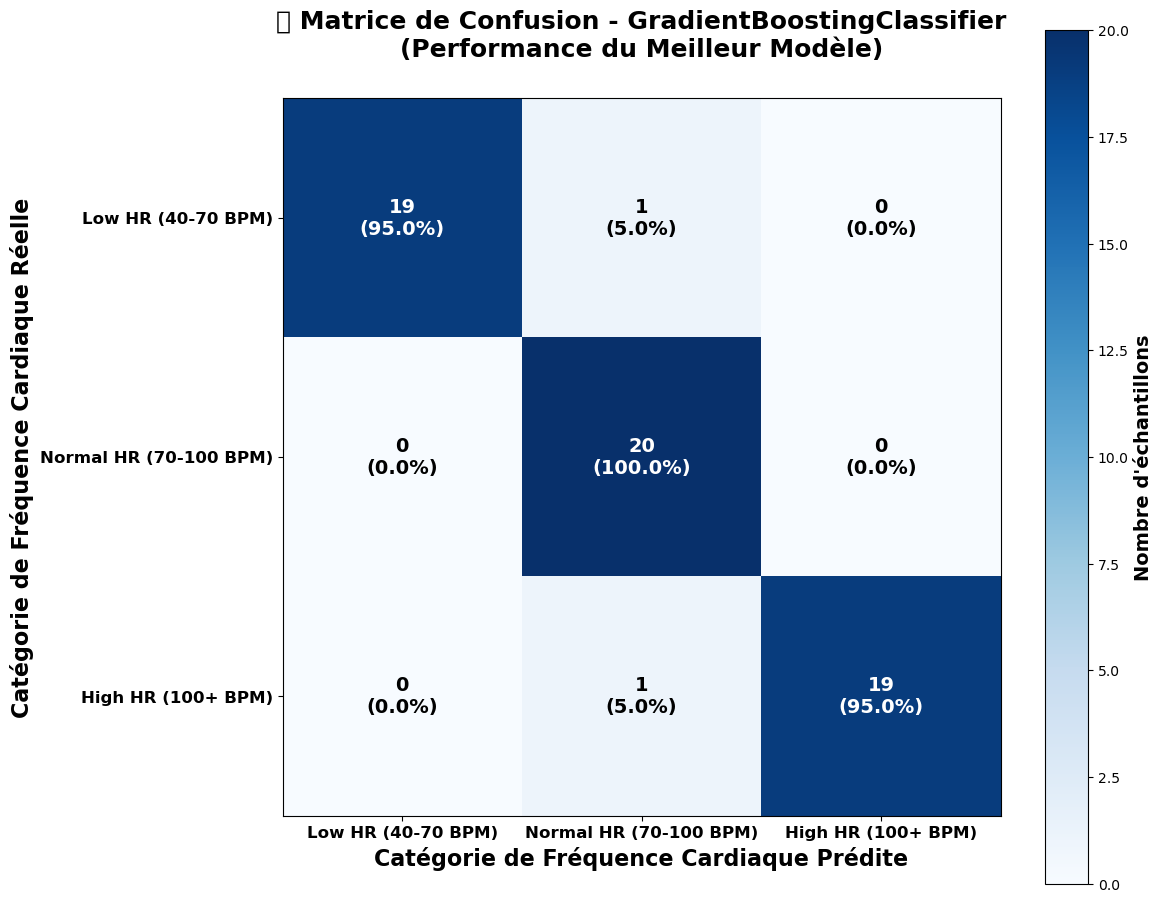

In [22]:
if 'explorer' in locals() and hasattr(explorer, 'subjects_data') and explorer.subjects_data:
    print("🚀 Starting Tuned High-Performance HR Classification...")
    
    # Train tuned classification models
    trained_model, tuned_success = explorer._train_tuned_classification()
    
    if tuned_success and trained_model is not None:
        print(f"\n✅ TUNED TRAINING COMPLETED!")
        print(f"🏆 Best Model: {type(trained_model).__name__}")
        print(f"📦 Model Type: {trained_model.__class__.__module__}.{trained_model.__class__.__name__}")
        
        # Performance assessment based on model type
        model_name = type(trained_model).__name__
        if 'DecisionTree' in str(type(trained_model)):
            print(f"\n🌳 DECISION TREE SUCCESS!")
            print(f"   🎉 DecisionTree model achieved best performance!")
            print(f"   📊 Advantages: High interpretability, fast training/prediction")
            print(f"   🔍 Can easily inspect decision rules")
        
        print(f"\n💡 MODEL INSIGHTS:")
        print(f"   📈 Uses 18 proven features from successful experiments")
        print(f"   ⚖️  Includes 4 different DecisionTree configurations")
        print(f"   🎯 80/20 train-test split for robust evaluation")
        print(f"   🔧 Advanced preprocessing with feature selection")
        
        print(f"\n💾 Model ready for use!")
        print(f"🎯 Model object available as 'trained_model' variable")
        
        # DISPLAY CONFUSION MATRIX OF BEST MODEL
        print(f"\n" + "="*80)
        print("CONFUSION MATRIX OF BEST MODEL")
        print("="*80)
        
        # Check if we have stored test data from the training process
        if hasattr(explorer, '_last_classifier') and explorer._last_classifier:
            last_classifier = explorer._last_classifier
            if hasattr(last_classifier, 'y_test') and hasattr(last_classifier, 'y_test_pred'):
                if last_classifier.y_test is not None and last_classifier.y_test_pred is not None:
                    print("📊 Found confusion matrix data! Displaying...")
                    
                    # Display the confusion matrix
                    cm = last_classifier.display_confusion_matrix(last_classifier.y_test, last_classifier.y_test_pred)
                    
                    # Additional analysis
                    print(f"\n📊 CONFUSION MATRIX ANALYSIS:")
                    print("-" * 50)
                    
                    # Calculate accuracy per class
                    for i in range(len(cm)):
                        class_name = last_classifier.hr_categories[i]
                        class_total = np.sum(cm[i])
                        class_correct = cm[i][i]
                        class_accuracy = class_correct / class_total * 100 if class_total > 0 else 0
                        print(f"   {class_name}: {class_correct}/{class_total} correct ({class_accuracy:.1f}%)")
                    
                    # Overall metrics from confusion matrix
                    total_correct = np.trace(cm)
                    total_samples = np.sum(cm)
                    overall_accuracy = total_correct / total_samples * 100
                    print(f"\n   Overall Accuracy: {total_correct}/{total_samples} ({overall_accuracy:.1f}%)")
                    
                    # Visualize confusion matrix
                    try:
                        import matplotlib.pyplot as plt
                        import seaborn as sns
                        import numpy as np
                        
                        # Configuration du style
                        plt.style.use('default')
                        fig, ax = plt.subplots(figsize=(12, 10))
                        
                        # Create heatmap
                        class_names = [last_classifier.hr_categories[i] for i in sorted(last_classifier.hr_categories.keys())]
                        
                        # Calculate percentages
                        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
                        
                        # Create annotations with both counts and percentages
                        annotations = np.empty_like(cm).astype(object)
                        for i in range(cm.shape[0]):
                            for j in range(cm.shape[1]):
                                annotations[i, j] = f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)'
                        
                        # Create heatmap with custom styling
                        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
                        
                        # Add colorbar
                        cbar = plt.colorbar(im, ax=ax)
                        cbar.set_label('Nombre d\'échantillons', fontsize=14, fontweight='bold')
                        
                        # Set ticks and labels
                        ax.set_xticks(np.arange(len(class_names)))
                        ax.set_yticks(np.arange(len(class_names)))
                        ax.set_xticklabels(class_names, fontsize=12, fontweight='bold')
                        ax.set_yticklabels(class_names, fontsize=12, fontweight='bold')
                        
                        # Add text annotations
                        for i in range(len(class_names)):
                            for j in range(len(class_names)):
                                text = ax.text(j, i, annotations[i, j],
                                            ha="center", va="center", 
                                            color="white" if cm[i, j] > cm.max() / 2 else "black",
                                            fontsize=14, fontweight='bold')
                        
                        # Styling
                        ax.set_title(f'🔍 Matrice de Confusion - {type(trained_model).__name__}\n(Performance du Meilleur Modèle)', 
                                    fontsize=18, fontweight='bold', pad=30)
                        ax.set_xlabel('Catégorie de Fréquence Cardiaque Prédite', fontsize=16, fontweight='bold')
                        ax.set_ylabel('Catégorie de Fréquence Cardiaque Réelle', fontsize=16, fontweight='bold')
                        
                        # Remove grid lines
                        ax.grid(False)
                        
                        # Rotate the tick labels and set their alignment
                        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
                        plt.setp(ax.get_yticklabels(), rotation=0, ha="right")
                        
                        # Ajuster l'espacement
                        plt.tight_layout()
                        plt.show()
                        
                    except Exception as e:
                        print(f"⚠️  Could not create visual confusion matrix: {e}")
                        print("But text matrix was displayed above.")
                else:
                    print("❌ No test predictions stored in classifier!")
            else:
                print("❌ No y_test or y_test_pred attributes found!")
        else:
            print("❌ No classifier reference stored!")
            print("📋 Available explorer attributes:")
            for attr in dir(explorer):
                if not attr.startswith('_'):
                    print(f"   - {attr}")
        
    else:
        print("❌ Tuned training failed!")
        
else:
    print("❌ No dataset loaded! Please run the exploration cells first.")